In [43]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

df_confirmed = pd.read_csv('../data/raw/confirmed_global.csv')
df_deaths    = pd.read_csv('../data/raw/deaths_global.csv')
df_recovered = pd.read_csv('../data/raw/recovered_global.csv')
df_owid      = pd.read_csv('../data/raw/owid_covid.csv', parse_dates=['date'])

print("Confirmed:", df_confirmed.shape)
print("Deaths   :", df_deaths.shape)
print("Recovered:", df_recovered.shape)
print("OWID     :", df_owid.shape)

Confirmed: (289, 1147)
Deaths   : (289, 1147)
Recovered: (274, 1147)
OWID     : (429435, 67)


In [44]:
def melt_jhu(df, value_name):
    """Wide format → Long format"""
    id_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
    date_cols = [c for c in df.columns if c not in id_cols]
    
    df_long = df.melt(
        id_vars    = id_cols,
        value_vars = date_cols,
        var_name   = 'date',
        value_name = value_name
    )
    df_long['date'] = pd.to_datetime(df_long['date'], format='%m/%d/%y')
    return df_long

df_conf_long   = melt_jhu(df_confirmed, 'confirmed')
df_deaths_long = melt_jhu(df_deaths,    'deaths')


df = pd.merge(
    df_conf_long,
    df_deaths_long[['Province/State','Country/Region','date','deaths']],
    on  = ['Province/State','Country/Region','date'],
    how = 'left'
)

print(df.shape)
print(df.dtypes)
df.head()

(330327, 7)
Province/State            object
Country/Region            object
Lat                      float64
Long                     float64
date              datetime64[ns]
confirmed                  int64
deaths                     int64
dtype: object


,Province/State,Country/Region,Lat,Long,date,confirmed,deaths
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0


In [45]:

df_country = (
    df.groupby(['Country/Region', 'date'], as_index=False)
      .agg({'confirmed': 'sum', 'deaths': 'sum'})
)


df_country = df_country.sort_values(['Country/Region', 'date'])
df_country['new_cases']  = df_country.groupby('Country/Region')['confirmed'].diff().fillna(0)
df_country['new_deaths'] = df_country.groupby('Country/Region')['deaths'].diff().fillna(0)


df_country['new_cases']  = df_country['new_cases'].clip(lower=0)
df_country['new_deaths'] = df_country['new_deaths'].clip(lower=0)

print(f"Countries: {df_country['Country/Region'].nunique()}")
print(f"Date range: {df_country['date'].min()} → {df_country['date'].max()}")
df_country.head(10)

Countries: 201
Date range: 2020-01-22 00:00:00 → 2023-03-09 00:00:00


,Country/Region,date,confirmed,deaths,new_cases,new_deaths
0,Afghanistan,2020-01-22,0,0,0.0,0.0
1,Afghanistan,2020-01-23,0,0,0.0,0.0
2,Afghanistan,2020-01-24,0,0,0.0,0.0
3,Afghanistan,2020-01-25,0,0,0.0,0.0
4,Afghanistan,2020-01-26,0,0,0.0,0.0
5,Afghanistan,2020-01-27,0,0,0.0,0.0
6,Afghanistan,2020-01-28,0,0,0.0,0.0
7,Afghanistan,2020-01-29,0,0,0.0,0.0
8,Afghanistan,2020-01-30,0,0,0.0,0.0
9,Afghanistan,2020-01-31,0,0,0.0,0.0


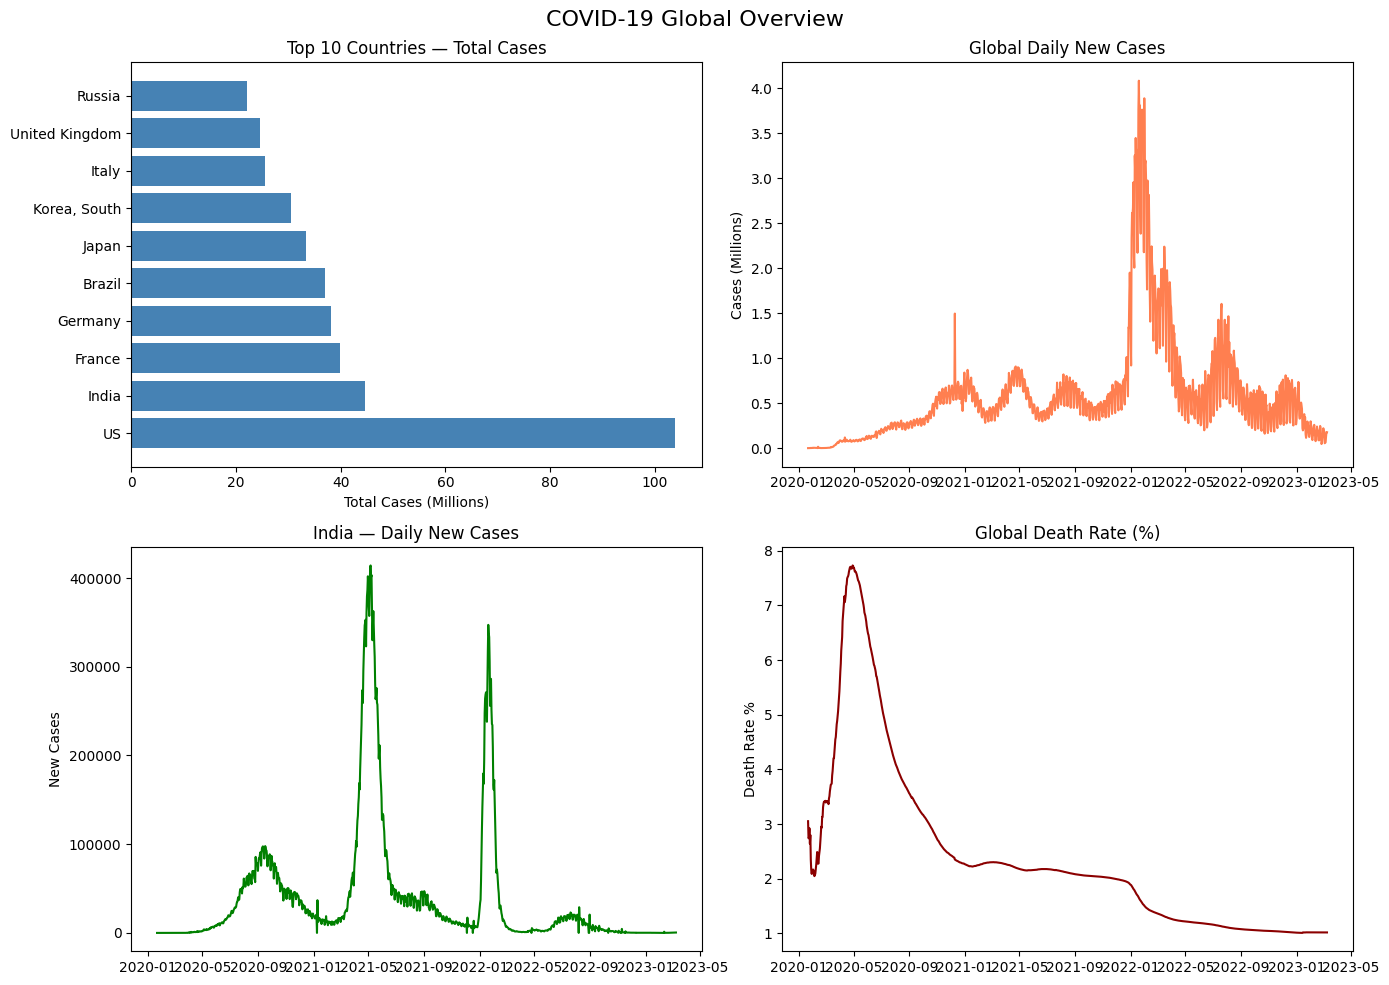

Plot saved!


In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('COVID-19 Global Overview', fontsize=16)

# Plot 1: Top 10 countries by total cases
top10 = (df_country.groupby('Country/Region')['confirmed']
         .max().nlargest(10).reset_index())
axes[0,0].barh(top10['Country/Region'], top10['confirmed'] / 1e6, color='steelblue')
axes[0,0].set_xlabel('Total Cases (Millions)')
axes[0,0].set_title('Top 10 Countries — Total Cases')

# Plot 2: Global daily new cases
global_daily = df_country.groupby('date')['new_cases'].sum().reset_index()
axes[0,1].plot(global_daily['date'], global_daily['new_cases'] / 1e6, color='coral')
axes[0,1].set_title('Global Daily New Cases')
axes[0,1].set_ylabel('Cases (Millions)')

# Plot 3: India trend
india = df_country[df_country['Country/Region'] == 'India']
axes[1,0].plot(india['date'], india['new_cases'], color='green')
axes[1,0].set_title('India — Daily New Cases')
axes[1,0].set_ylabel('New Cases')

# Plot 4: Death rate over time (global)
global_agg = df_country.groupby('date')[['confirmed','deaths']].sum()
global_agg['death_rate'] = global_agg['deaths'] / global_agg['confirmed'].replace(0, np.nan) * 100
axes[1,1].plot(global_agg.index, global_agg['death_rate'], color='darkred')
axes[1,1].set_title('Global Death Rate (%)')
axes[1,1].set_ylabel('Death Rate %')

plt.tight_layout()
plt.savefig('../data/raw/eda_overview.png', dpi=150)
plt.show()
print("Plot saved!")

In [47]:
df_country.to_csv('../data/processed/covid_country_daily.csv', index=False)
print(f"Saved! Shape: {df_country.shape}")
print(df_country[df_country['Country/Region']=='India'].tail(5))

Saved! Shape: (229743, 6)
      Country/Region       date  confirmed  deaths  new_cases  new_deaths
92578          India 2023-03-05   44689327  530775      281.0         0.0
92579          India 2023-03-06   44689593  530775      266.0         0.0
92580          India 2023-03-07   44689919  530775      326.0         0.0
92581          India 2023-03-08   44690298  530776      379.0         1.0
92582          India 2023-03-09   44690738  530779      440.0         3.0


In [48]:
print(df_owid.columns.tolist())
print(df_owid.shape)
df_owid.head(3)

['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'total_

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [49]:
owid_cols = [
    'location',           # country name
    'date',               # date
    'new_vaccinations',   # daily vaccinations
    'people_vaccinated',  # total vaccinated
    'hospital_beds_per_thousand',  # healthcare capacity
    'population',         # population
    'population_density', # density
    'gdp_per_capita',     # economic factor
    'median_age',         # age factor
]

df_owid_slim = df_owid[owid_cols].copy()
df_owid_slim['date'] = pd.to_datetime(df_owid_slim['date'])

print(df_owid_slim.shape)
df_owid_slim.head(3)

(429435, 9)


,location,date,new_vaccinations,people_vaccinated,hospital_beds_per_thousand,population,population_density,gdp_per_capita,median_age
0,Afghanistan,2020-01-05,NaN,NaN,0.5,41128772,54.42,1803.99,18.6
1,Afghanistan,2020-01-06,NaN,NaN,0.5,41128772,54.42,1803.99,18.6
2,Afghanistan,2020-01-07,NaN,NaN,0.5,41128772,54.42,1803.99,18.6


In [50]:
df_merged = pd.merge(
    df_country,
    df_owid_slim,
    left_on  = ['Country/Region', 'date'],
    right_on = ['location', 'date'],
    how      = 'left'
)


df_merged.drop(columns=['location'], inplace=True)

print("Merged shape:", df_merged.shape)
print("Columns:", df_merged.columns.tolist())
df_merged.head(5)

Merged shape: (229743, 13)
Columns: ['Country/Region', 'date', 'confirmed', 'deaths', 'new_cases', 'new_deaths', 'new_vaccinations', 'people_vaccinated', 'hospital_beds_per_thousand', 'population', 'population_density', 'gdp_per_capita', 'median_age']


,Country/Region,date,confirmed,deaths,new_cases,new_deaths,new_vaccinations,people_vaccinated,hospital_beds_per_thousand,population,population_density,gdp_per_capita,median_age
0,Afghanistan,2020-01-22,0,0,0.0,0.0,NaN,NaN,0.5,41128772.0,54.42,1803.99,18.6
1,Afghanistan,2020-01-23,0,0,0.0,0.0,NaN,NaN,0.5,41128772.0,54.42,1803.99,18.6
2,Afghanistan,2020-01-24,0,0,0.0,0.0,NaN,NaN,0.5,41128772.0,54.42,1803.99,18.6
3,Afghanistan,2020-01-25,0,0,0.0,0.0,NaN,NaN,0.5,41128772.0,54.42,1803.99,18.6
4,Afghanistan,2020-01-26,0,0,0.0,0.0,NaN,NaN,0.5,41128772.0,54.42,1803.99,18.6


In [51]:
missing = df_merged.isnull().sum()
missing_pct = (missing / len(df_merged) * 100).round(1)

summary = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).sort_values('missing_%', ascending=False)

print(summary[summary['missing_count'] > 0])

                            missing_count  missing_%
new_vaccinations                   187487       81.6
people_vaccinated                  179668       78.2
hospital_beds_per_thousand          41148       17.9
median_age                          32004       13.9
gdp_per_capita                      26289       11.4
population_density                  21717        9.5
population                          19431        8.5


In [52]:
df_merged.to_csv('../data/processed/covid_merged.csv', index=False)
print(f"Saved! Shape: {df_merged.shape}")


df_merged[df_merged['Country/Region'] == 'India'][
    ['Country/Region','date','confirmed','new_cases','new_vaccinations','population']
].tail(5)

Saved! Shape: (229743, 13)


,Country/Region,date,confirmed,new_cases,new_vaccinations,population
92578,India,2023-03-05,44689327,281.0,5875.0,1.417173e+09
92579,India,2023-03-06,44689593,266.0,1664.0,1.417173e+09
92580,India,2023-03-07,44689919,326.0,5135.0,1.417173e+09
92581,India,2023-03-08,44690298,379.0,2862.0,1.417173e+09
92582,India,2023-03-09,44690738,440.0,2712.0,1.417173e+09


In [53]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/covid_merged.csv', parse_dates=['date'])

print("=" * 50)
print(f"Shape        : {df.shape}")
print(f"Date range   : {df['date'].min()} → {df['date'].max()}")
print(f"Countries    : {df['Country/Region'].nunique()}")
print(f"Columns      : {df.columns.tolist()}")
print("=" * 50)

# Missing values
missing = (df.isnull().sum() / len(df) * 100).round(1)
print("\nMissing % per column:")
print(missing[missing > 0].sort_values(ascending=False))

Shape        : (229743, 13)
Date range   : 2020-01-22 00:00:00 → 2023-03-09 00:00:00
Countries    : 201
Columns      : ['Country/Region', 'date', 'confirmed', 'deaths', 'new_cases', 'new_deaths', 'new_vaccinations', 'people_vaccinated', 'hospital_beds_per_thousand', 'population', 'population_density', 'gdp_per_capita', 'median_age']

Missing % per column:
new_vaccinations              81.6
people_vaccinated             78.2
hospital_beds_per_thousand    17.9
median_age                    13.9
gdp_per_capita                11.4
population_density             9.5
population                     8.5
dtype: float64


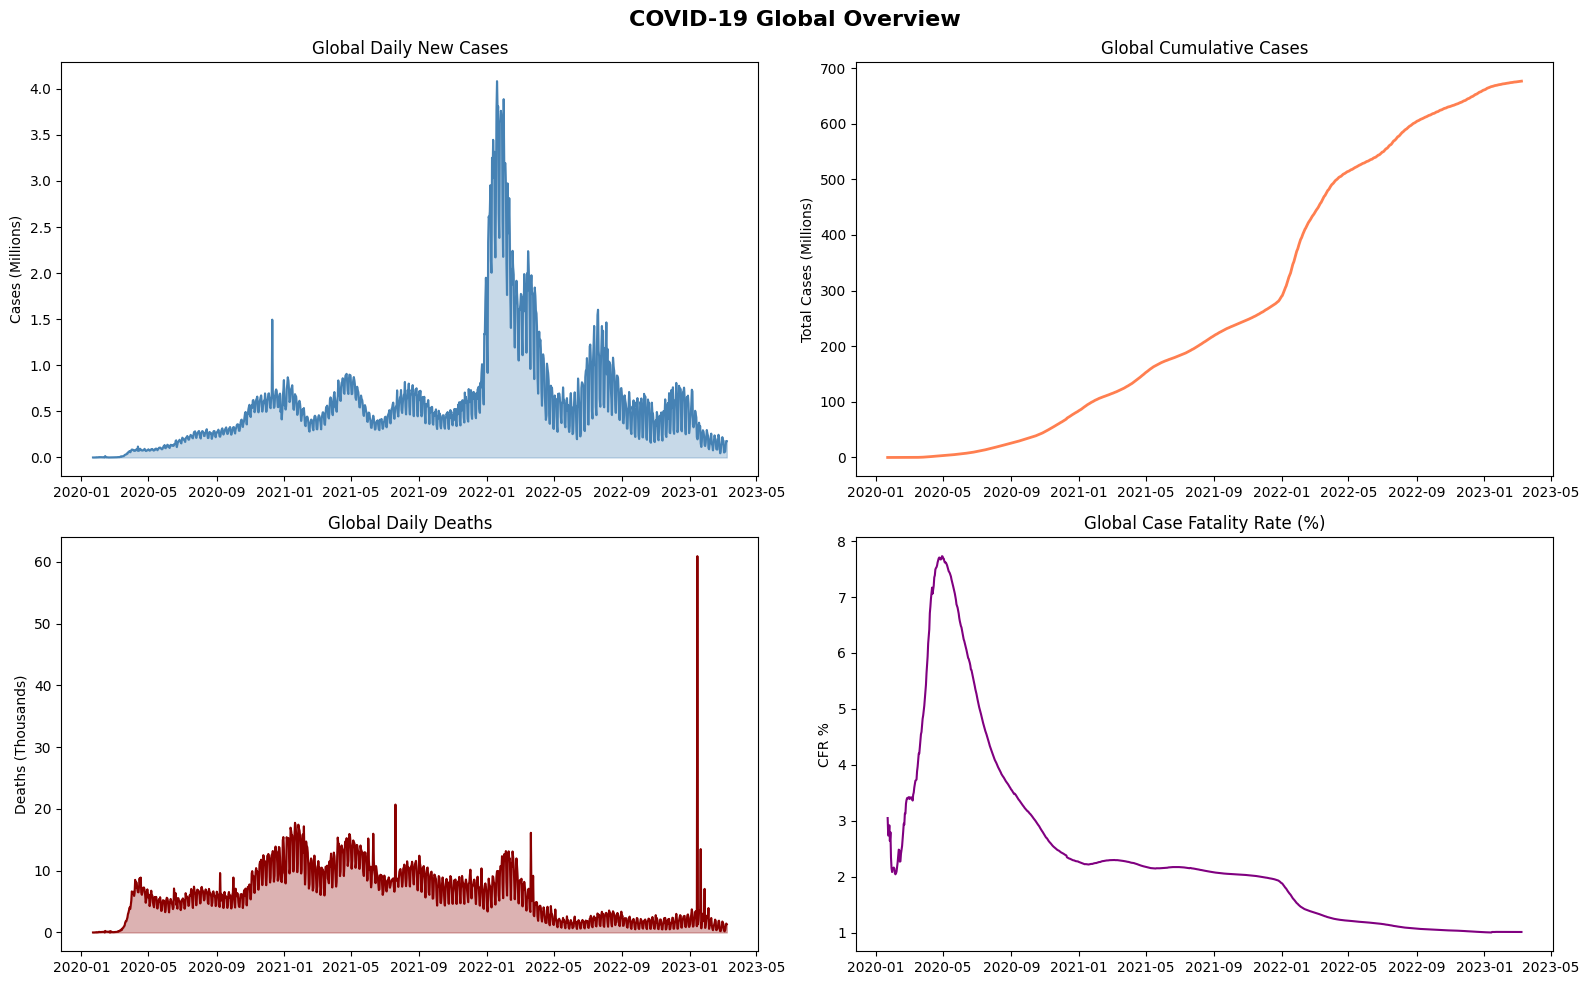

Plot 1 saved!


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('COVID-19 Global Overview', fontsize=16, fontweight='bold')

# Plot 1 — Global daily new cases
global_daily = df.groupby('date')['new_cases'].sum().reset_index()
axes[0,0].plot(global_daily['date'], global_daily['new_cases']/1e6, 
               color='steelblue', linewidth=1.5)
axes[0,0].fill_between(global_daily['date'], 
                        global_daily['new_cases']/1e6, alpha=0.3, color='steelblue')
axes[0,0].set_title('Global Daily New Cases')
axes[0,0].set_ylabel('Cases (Millions)')

# Plot 2 — Global cumulative cases
global_cum = df.groupby('date')['confirmed'].sum().reset_index()
axes[0,1].plot(global_cum['date'], global_cum['confirmed']/1e6, 
               color='coral', linewidth=2)
axes[0,1].set_title('Global Cumulative Cases')
axes[0,1].set_ylabel('Total Cases (Millions)')

# Plot 3 — Global daily deaths
global_deaths = df.groupby('date')['new_deaths'].sum().reset_index()
axes[1,0].plot(global_deaths['date'], global_deaths['new_deaths']/1e3,
               color='darkred', linewidth=1.5)
axes[1,0].fill_between(global_deaths['date'],
                        global_deaths['new_deaths']/1e3, alpha=0.3, color='darkred')
axes[1,0].set_title('Global Daily Deaths')
axes[1,0].set_ylabel('Deaths (Thousands)')

# Plot 4 — Death rate over time
global_agg = df.groupby('date')[['confirmed','deaths']].sum()
global_agg['death_rate'] = (global_agg['deaths'] / 
                             global_agg['confirmed'].replace(0, np.nan) * 100)
axes[1,1].plot(global_agg.index, global_agg['death_rate'], 
               color='purple', linewidth=1.5)
axes[1,1].set_title('Global Case Fatality Rate (%)')
axes[1,1].set_ylabel('CFR %')

plt.tight_layout()
plt.savefig('../data/raw/plot1_global_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

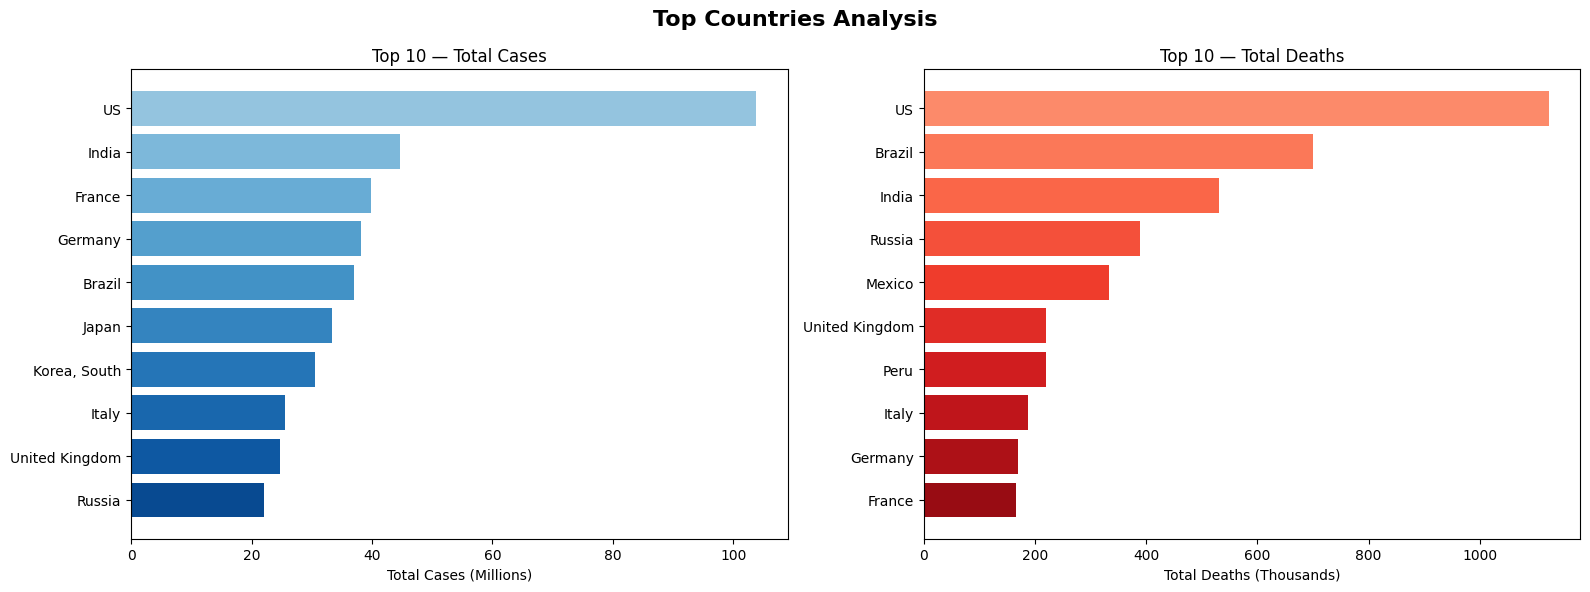

Plot 2 saved!


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Countries Analysis', fontsize=16, fontweight='bold')

# Plot 1 — Top 10 by total cases
top10_cases = (df.groupby('Country/Region')['confirmed']
               .max().nlargest(10).reset_index())
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
axes[0].barh(top10_cases['Country/Region'], 
             top10_cases['confirmed']/1e6, color=colors)
axes[0].set_xlabel('Total Cases (Millions)')
axes[0].set_title('Top 10 — Total Cases')
axes[0].invert_yaxis()

# Plot 2 — Top 10 by total deaths
top10_deaths = (df.groupby('Country/Region')['deaths']
                .max().nlargest(10).reset_index())
colors2 = plt.cm.Reds(np.linspace(0.4, 0.9, 10))
axes[1].barh(top10_deaths['Country/Region'],
             top10_deaths['deaths']/1e3, color=colors2)
axes[1].set_xlabel('Total Deaths (Thousands)')
axes[1].set_title('Top 10 — Total Deaths')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/raw/plot2_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

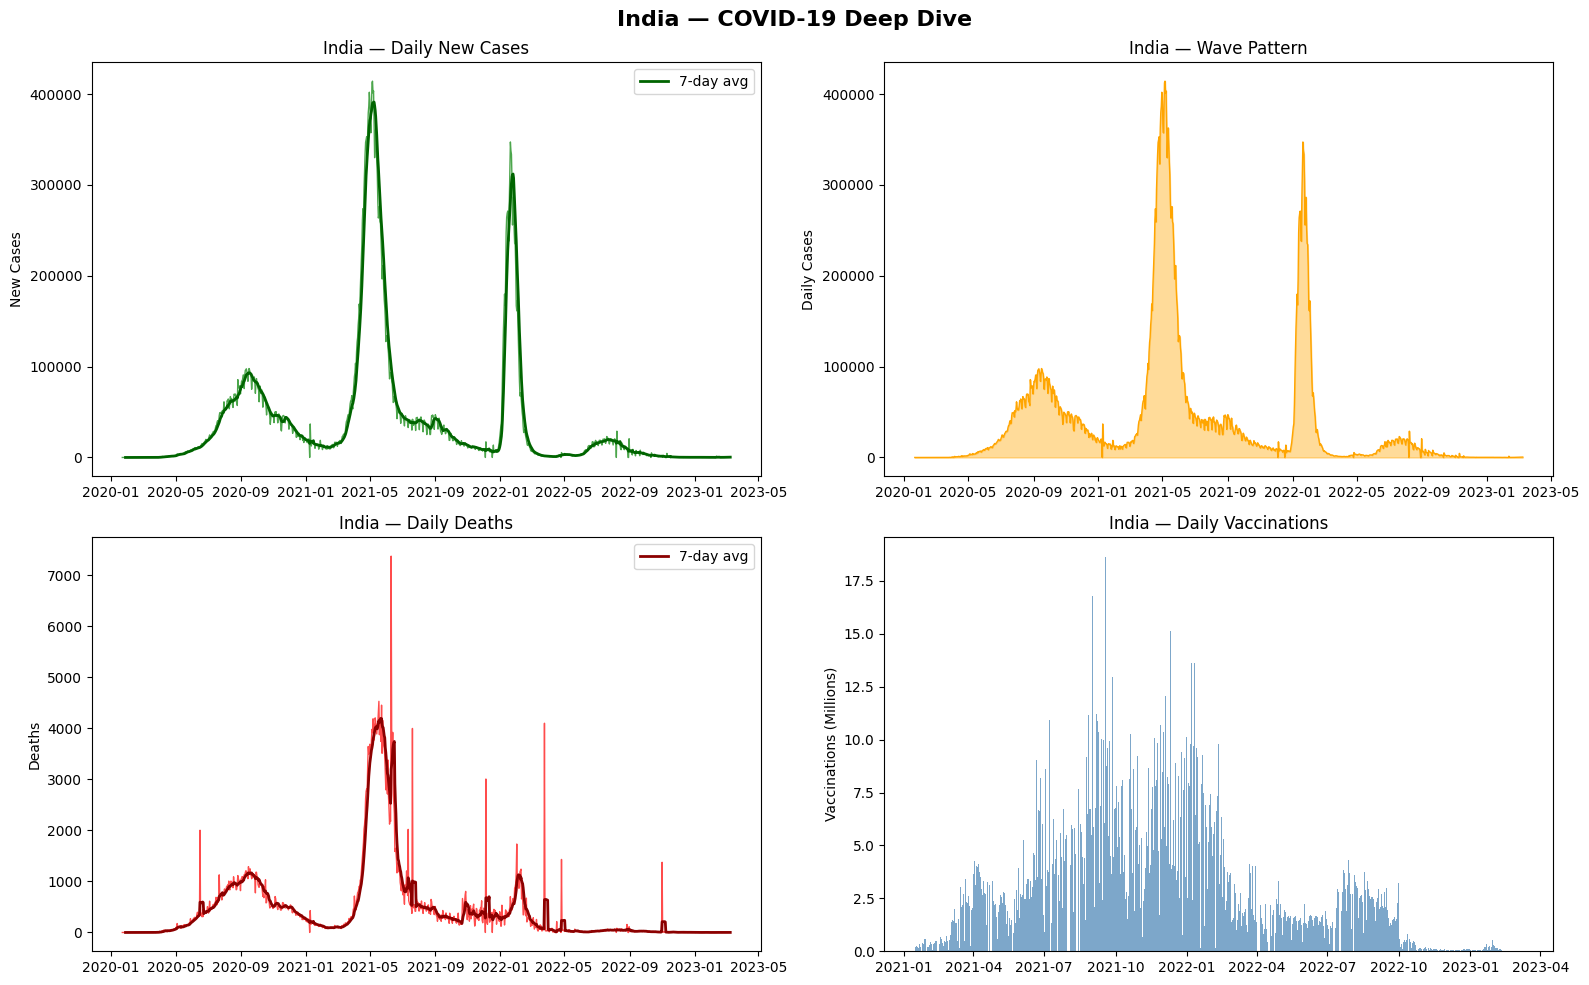

Plot 3 saved!


In [56]:
india = df[df['Country/Region'] == 'India'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('India — COVID-19 Deep Dive', fontsize=16, fontweight='bold')

# Plot 1 — Daily new cases India
axes[0,0].plot(india['date'], india['new_cases'], 
               color='green', linewidth=1, alpha=0.7)
# 7-day rolling average
india['rolling_7'] = india['new_cases'].rolling(7).mean()
axes[0,0].plot(india['date'], india['rolling_7'], 
               color='darkgreen', linewidth=2, label='7-day avg')
axes[0,0].set_title('India — Daily New Cases')
axes[0,0].set_ylabel('New Cases')
axes[0,0].legend()

# Plot 2 — India waves (identify peaks)
axes[0,1].plot(india['date'], india['new_cases'], color='orange', linewidth=1)
axes[0,1].fill_between(india['date'], india['new_cases'], alpha=0.4, color='orange')
axes[0,1].set_title('India — Wave Pattern')
axes[0,1].set_ylabel('Daily Cases')

# Plot 3 — India deaths
axes[1,0].plot(india['date'], india['new_deaths'],
               color='red', linewidth=1, alpha=0.7)
india['deaths_rolling'] = india['new_deaths'].rolling(7).mean()
axes[1,0].plot(india['date'], india['deaths_rolling'],
               color='darkred', linewidth=2, label='7-day avg')
axes[1,0].set_title('India — Daily Deaths')
axes[1,0].set_ylabel('Deaths')
axes[1,0].legend()

# Plot 4 — India vaccinations (if available)
if 'new_vaccinations' in india.columns:
    india_vax = india.dropna(subset=['new_vaccinations'])
    axes[1,1].bar(india_vax['date'], india_vax['new_vaccinations']/1e6,
                  color='steelblue', alpha=0.7, width=1)
    axes[1,1].set_title('India — Daily Vaccinations')
    axes[1,1].set_ylabel('Vaccinations (Millions)')
else:
    axes[1,1].text(0.5, 0.5, 'Vaccination data\nnot available',
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.savefig('../data/raw/plot3_india_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

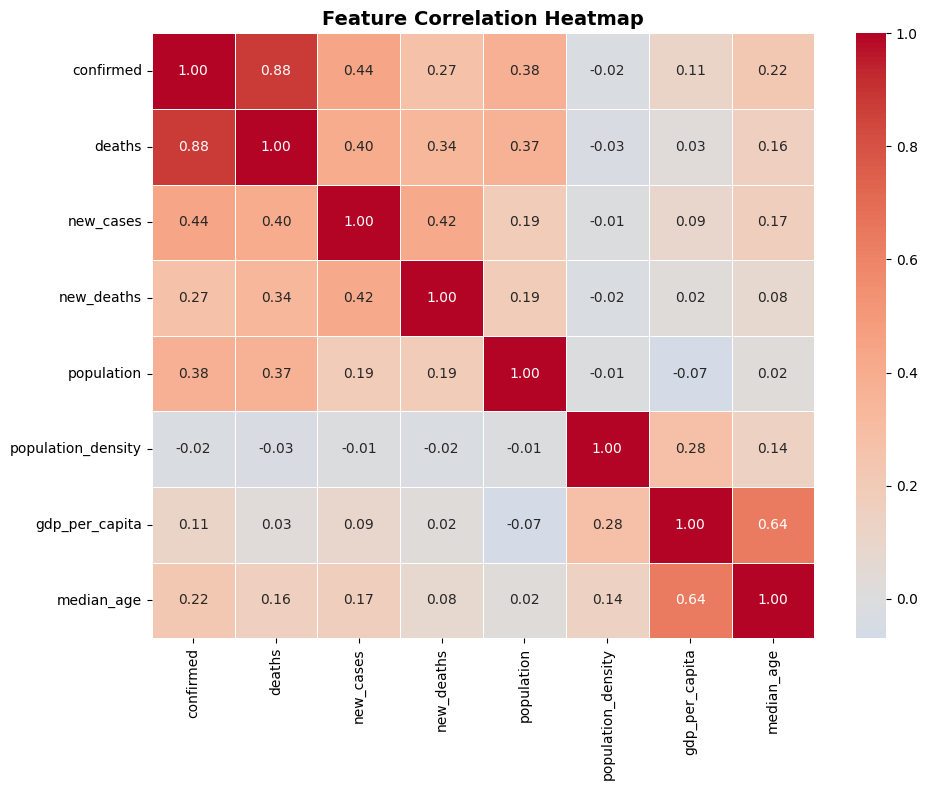

Plot 4 saved!


In [57]:
# Numeric columns's correlation
num_cols = ['confirmed', 'deaths', 'new_cases', 'new_deaths',
            'population', 'population_density', 'gdp_per_capita', 'median_age']


available = [c for c in num_cols if c in df.columns]
corr_df = df[available].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/raw/plot4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved!")

In [58]:
print("=" * 60)
print("KEY EDA INSIGHTS")
print("=" * 60)

total_cases  = df.groupby('Country/Region')['confirmed'].max().sum()
total_deaths = df.groupby('Country/Region')['deaths'].max().sum()
peak_day     = global_daily.loc[global_daily['new_cases'].idxmax()]
worst_country = df.groupby('Country/Region')['confirmed'].max().idxmax()

print(f"Total global cases   : {total_cases/1e6:.1f} Million")
print(f"Total global deaths  : {total_deaths/1e6:.2f} Million")
print(f"Global CFR           : {total_deaths/total_cases*100:.2f}%")
print(f"Peak day globally    : {peak_day['date'].date()} "
      f"({peak_day['new_cases']/1e6:.1f}M cases)")
print(f"Most affected country: {worst_country}")

india_total = df[df['Country/Region']=='India']['confirmed'].max()
print(f"India total cases    : {india_total/1e6:.1f} Million")
print("=" * 60)

KEY EDA INSIGHTS
Total global cases   : 676.6 Million
Total global deaths  : 6.88 Million
Global CFR           : 1.02%
Peak day globally    : 2022-01-19 (4.1M cases)
Most affected country: US
India total cases    : 44.7 Million
